# Daily active users

Product-engagement metrics like daily active users have a recognizable shape: an underlying growth (or decay) trend, a strong weekly rhythm, and noise. `DailyActiveUsersGenerator` reproduces this for testing growth-analytics dashboards and anomaly detection on product metrics.

::: {.callout-note}
## The model

A growth trend is combined with weekly seasonality and noise to produce a realistic engagement curve. Tune the growth and seasonal strength to span fast-growing, mature, and declining products.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import DailyActiveUsersGenerator

## Consumer App (Social Media)

Generate 3 months of daily DAU data for a consumer app with organic growth and marketing events.

In [ ]:
consumer_params = {
    "min_length": 90,
    "max_length": 90,
    "freq": "D",
    "app_type": "consumer",
    "base_users": 50000.0,
    "growth_rate": 0.001,
    "event_probability": 0.03,
    "event_impact_min": 1.3,
    "event_impact_max": 1.8,
    "event_decay_rate": 0.15,
    "seed": 42,
}
consumer_gen = DailyActiveUsersGenerator(engine="polars", **consumer_params)
consumer_df = consumer_gen.generate(n_series=1)

print(f"Generated {len(consumer_df)} daily observations")
print(f"Columns: {consumer_df.columns}")
consumer_df.head(14)

Generated 90 daily observations
Columns: ['unique_id', 'ds', 'y', 'event']


unique_id,ds,y,event
cat,datetime[ns],f64,i32
"""0""",2000-01-01 00:00:00,47735.136215,0
"""0""",2000-01-02 00:00:00,50902.490456,0
"""0""",2000-01-03 00:00:00,48434.649342,0
"""0""",2000-01-04 00:00:00,49295.395926,0
"""0""",2000-01-05 00:00:00,50653.792226,0
…,…,…,…
"""0""",2000-01-10 00:00:00,55757.37744,0
"""0""",2000-01-11 00:00:00,49779.0814,0
"""0""",2000-01-12 00:00:00,51351.236124,0


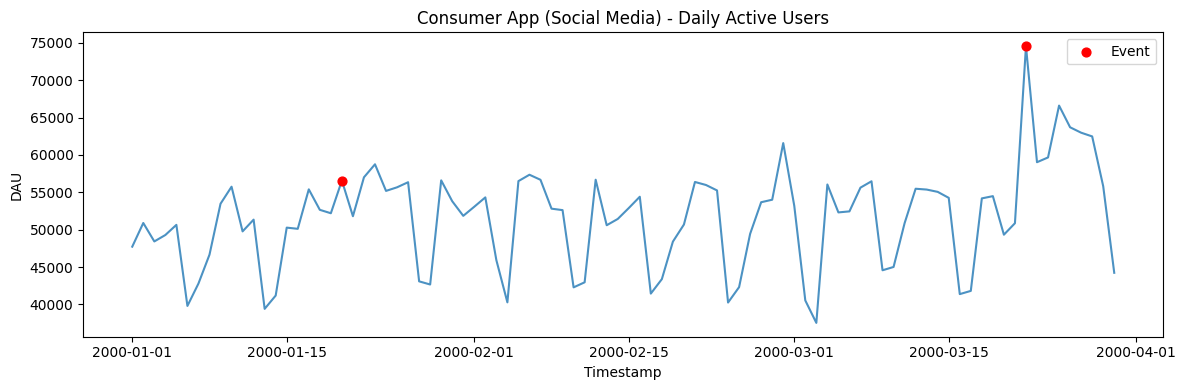

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(consumer_df["ds"].to_list(), consumer_df["y"].to_list(), alpha=0.8)
event_days = consumer_df.filter(pl.col("event") == 1)
if len(event_days) > 0:
    ax.scatter(event_days["ds"].to_list(), event_days["y"].to_list(), color="red", zorder=5, label="Event", s=40)
ax.set_xlabel("Timestamp")
ax.set_ylabel("DAU")
ax.set_title("Consumer App (Social Media) - Daily Active Users")
ax.legend()
plt.tight_layout()
plt.show()

### Event Statistics

Examine how often events occur and their impact on DAU.

In [ ]:
n_events = consumer_df["event"].sum()
print(f"Events occurred: {n_events} times ({n_events/len(consumer_df)*100:.1f}%)")
print(
    f"DAU Statistics: Mean={consumer_df['y'].mean():,.0f}, "
    f"Min={consumer_df['y'].min():,.0f}, Max={consumer_df['y'].max():,.0f}"
)

Events occurred: 2 times (2.2%)
DAU Statistics: Mean=51,637, Min=37,539, Max=74,558


## Business App (B2B SaaS)

Business apps show very low weekend usage and more stable growth patterns.

In [ ]:
business_params = {
    "min_length": 90,
    "max_length": 90,
    "freq": "D",
    "app_type": "business",
    "base_users": 5000.0,
    "growth_rate": 0.0005,
    "weekend_factor": 0.3,
    "event_probability": 0.02,
    "event_impact_min": 1.2,
    "event_impact_max": 1.5,
    "noise_std": 0.03,
    "seed": 42,
}
business_gen = DailyActiveUsersGenerator(engine="polars", **business_params)
business_df = business_gen.generate(n_series=1)

print(f"Generated {len(business_df)} daily observations")
print(
    f"DAU Statistics: Mean={business_df['y'].mean():,.0f}, "
    f"Min={business_df['y'].min():,.0f}, Max={business_df['y'].max():,.0f}"
)
business_df.head(14)

Generated 90 daily observations
DAU Statistics: Mean=4,248, Min=1,441, Max=6,467


unique_id,ds,y,event
cat,datetime[ns],f64,i32
"""0""",2000-01-01 00:00:00,4864.108173,0
"""0""",2000-01-02 00:00:00,5053.623878,0
"""0""",2000-01-03 00:00:00,4905.17701,0
"""0""",2000-01-04 00:00:00,4956.295316,0
"""0""",2000-01-05 00:00:00,5037.1627,0
…,…,…,…
"""0""",2000-01-10 00:00:00,5339.451229,0
"""0""",2000-01-11 00:00:00,4981.882098,0
"""0""",2000-01-12 00:00:00,5075.214947,0


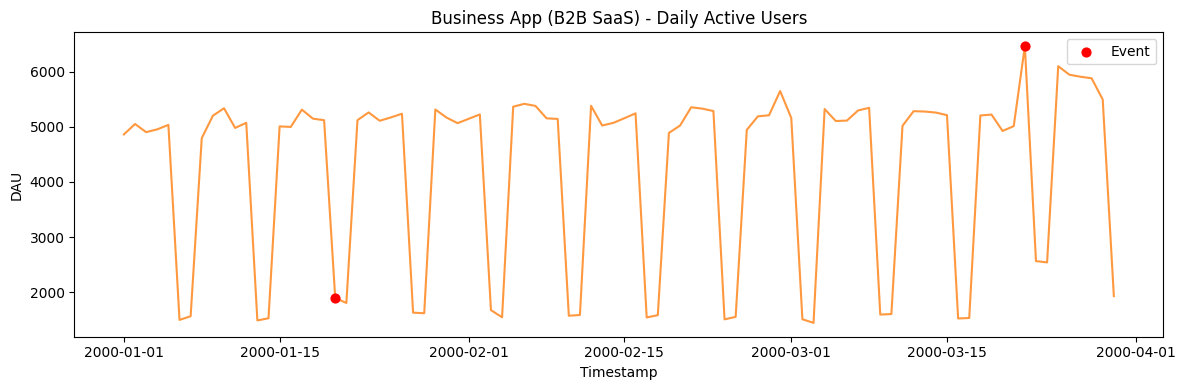

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(business_df["ds"].to_list(), business_df["y"].to_list(), alpha=0.8, color="C1")
event_days = business_df.filter(pl.col("event") == 1)
if len(event_days) > 0:
    ax.scatter(event_days["ds"].to_list(), event_days["y"].to_list(), color="red", zorder=5, label="Event", s=40)
ax.set_xlabel("Timestamp")
ax.set_ylabel("DAU")
ax.set_title("Business App (B2B SaaS) - Daily Active Users")
ax.legend()
plt.tight_layout()
plt.show()

## Gaming App

Gaming apps typically show higher weekend usage and more frequent events (game updates, tournaments).

In [ ]:
gaming_params = {
    "min_length": 90,
    "max_length": 90,
    "freq": "D",
    "app_type": "gaming",
    "base_users": 100000.0,
    "growth_rate": 0.002,
    "weekend_factor": 1.4,
    "event_probability": 0.05,
    "event_impact_min": 1.5,
    "event_impact_max": 2.5,
    "event_decay_rate": 0.2,
    "seed": 42,
}
gaming_gen = DailyActiveUsersGenerator(engine="polars", **gaming_params)
gaming_df = gaming_gen.generate(n_series=1)

n_events = gaming_df["event"].sum()
print(f"Generated {len(gaming_df)} daily observations")
print(f"Events occurred: {n_events} times (game updates, tournaments, etc.)")
print(
    f"DAU Statistics: Mean={gaming_df['y'].mean():,.0f}, "
    f"Min={gaming_df['y'].min():,.0f}, Max={gaming_df['y'].max():,.0f}"
)
gaming_df.head(14)

Generated 90 daily observations
Events occurred: 3 times (game updates, tournaments, etc.)
DAU Statistics: Mean=135,983, Min=95,470, Max=272,723


unique_id,ds,y,event
cat,datetime[ns],f64,i32
"""0""",2000-01-01 00:00:00,95470.27243,0
"""0""",2000-01-02 00:00:00,101906.684189,0
"""0""",2000-01-03 00:00:00,97062.940412,0
"""0""",2000-01-04 00:00:00,98886.564031,0
"""0""",2000-01-05 00:00:00,101713.017001,0
…,…,…,…
"""0""",2000-01-10 00:00:00,139500.258599,0
"""0""",2000-01-11 00:00:00,129672.160207,0
"""0""",2000-01-12 00:00:00,139542.59736,0


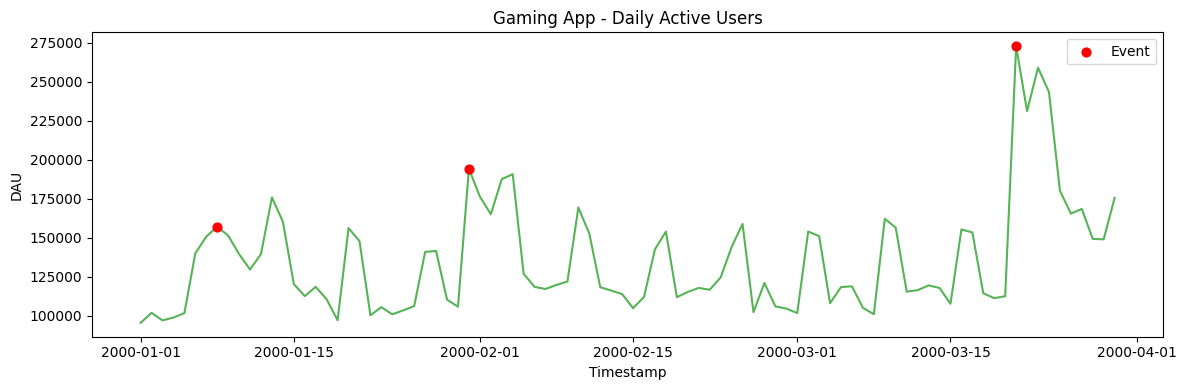

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(gaming_df["ds"].to_list(), gaming_df["y"].to_list(), alpha=0.8, color="C2")
event_days = gaming_df.filter(pl.col("event") == 1)
if len(event_days) > 0:
    ax.scatter(event_days["ds"].to_list(), event_days["y"].to_list(), color="red", zorder=5, label="Event", s=40)
ax.set_xlabel("Timestamp")
ax.set_ylabel("DAU")
ax.set_title("Gaming App - Daily Active Users")
ax.legend()
plt.tight_layout()
plt.show()

## Analyzing Event Impact

Compare DAU on event days versus normal days to measure the lift from marketing events.

In [ ]:
event_days = consumer_df.filter(pl.col("event") == 1)
if len(event_days) > 0:
    print("Days when events occurred:")
    print(event_days)

    avg_event_day = consumer_df.filter(pl.col("event") == 1)["y"].mean()
    avg_normal_day = consumer_df.filter(pl.col("event") == 0)["y"].mean()
    print(f"\nAverage DAU on event days: {avg_event_day:,.0f}")
    print(f"Average DAU on normal days: {avg_normal_day:,.0f}")
    print(f"Event day lift: {(avg_event_day/avg_normal_day - 1)*100:.1f}%")

Days when events occurred:
shape: (2, 4)
┌───────────┬─────────────────────┬──────────────┬───────┐
│ unique_id ┆ ds                  ┆ y            ┆ event │
│ ---       ┆ ---                 ┆ ---          ┆ ---   │
│ cat       ┆ datetime[ns]        ┆ f64          ┆ i32   │
╞═══════════╪═════════════════════╪══════════════╪═══════╡
│ 0         ┆ 2000-01-20 00:00:00 ┆ 56577.396413 ┆ 1     │
│ 0         ┆ 2000-03-22 00:00:00 ┆ 74557.509084 ┆ 1     │
└───────────┴─────────────────────┴──────────────┴───────┘

Average DAU on event days: 65,567
Average DAU on normal days: 51,320
Event day lift: 27.8%


## Hourly Active Users

The generator also supports sub-daily frequencies like hourly data.

In [ ]:
hourly_params = {
    "min_length": 168,
    "max_length": 168,
    "freq": "h",
    "app_type": "consumer",
    "base_users": 10000.0,
    "event_probability": 0.01,
    "noise_std": 0.08,
    "seed": 42,
}
hourly_gen = DailyActiveUsersGenerator(engine="polars", **hourly_params)
hourly_df = hourly_gen.generate(n_series=1)

print(f"Generated {len(hourly_df)} hourly observations")
hourly_df.head(24)

Generated 168 hourly observations


unique_id,ds,y,event
cat,datetime[ns],f64,i32
"""0""",2000-01-01 00:00:00,9275.243589,0
"""0""",2000-01-01 01:00:00,10272.524421,0
"""0""",2000-01-01 02:00:00,9468.136049,0
"""0""",2000-01-01 03:00:00,9727.297606,0
"""0""",2000-01-01 04:00:00,10144.538427,0
…,…,…,…
"""0""",2000-01-01 19:00:00,13346.974807,1
"""0""",2000-01-01 20:00:00,12068.154452,0
"""0""",2000-01-01 21:00:00,10815.974473,0


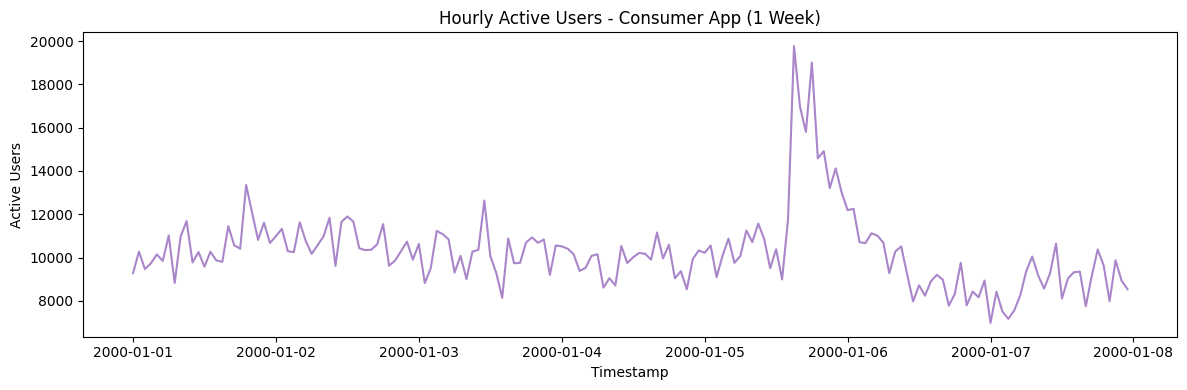

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_df["ds"].to_list(), hourly_df["y"].to_list(), alpha=0.8, color="C4")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Active Users")
ax.set_title("Hourly Active Users - Consumer App (1 Week)")
plt.tight_layout()
plt.show()

## Multiple Products/Apps

Generate DAU data for multiple products simultaneously and compare event distributions.

In [ ]:
multi_params = {
    "min_length": 30,
    "max_length": 30,
    "freq": "D",
    "app_type": "consumer",
    "base_users": 20000.0,
    "event_probability": 0.03,
    "seed": 42,
}
multi_gen = DailyActiveUsersGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=5)

print(f"Generated 5 products with {len(multi_df)} total observations")
print("\nProduct 0 preview:")
print(multi_df.filter(pl.col("unique_id") == "0").head(10))

total_events = multi_df.group_by("unique_id").agg(pl.col("event").sum())
print("\nEvents per product:")
print(total_events)

Generated 5 products with 150 total observations

Product 0 preview:
shape: (10, 4)
┌───────────┬─────────────────────┬──────────────┬───────┐
│ unique_id ┆ ds                  ┆ y            ┆ event │
│ ---       ┆ ---                 ┆ ---          ┆ ---   │
│ cat       ┆ datetime[ns]        ┆ f64          ┆ i32   │
╞═══════════╪═════════════════════╪══════════════╪═══════╡
│ 0         ┆ 2000-01-01 00:00:00 ┆ 19094.054486 ┆ 0     │
│ 0         ┆ 2000-01-02 00:00:00 ┆ 20350.825855 ┆ 0     │
│ 0         ┆ 2000-01-03 00:00:00 ┆ 19354.510065 ┆ 0     │
│ 0         ┆ 2000-01-04 00:00:00 ┆ 19688.625437 ┆ 0     │
│ 0         ┆ 2000-01-05 00:00:00 ┆ 20221.064661 ┆ 0     │
│ 0         ┆ 2000-01-06 00:00:00 ┆ 15882.965767 ┆ 0     │
│ 0         ┆ 2000-01-07 00:00:00 ┆ 17069.908021 ┆ 0     │
│ 0         ┆ 2000-01-08 00:00:00 ┆ 18599.75721  ┆ 0     │
│ 0         ┆ 2000-01-09 00:00:00 ┆ 21305.138222 ┆ 0     │
│ 0         ┆ 2000-01-10 00:00:00 ┆ 22202.888052 ┆ 0     │
└───────────┴──────────────────

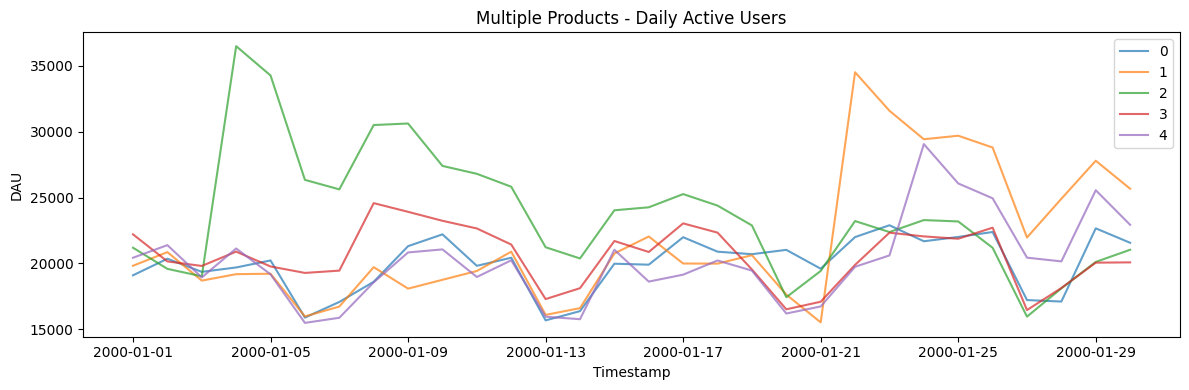

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.7)
ax.set_xlabel("Timestamp")
ax.set_ylabel("DAU")
ax.set_title("Multiple Products - Daily Active Users")
ax.legend()
plt.tight_layout()
plt.show()

## Custom Column Names

Customize the output column names to match your application's naming conventions.

In [ ]:
custom_params = {
    "min_length": 30,
    "max_length": 30,
    "freq": "D",
    "base_users": 15000.0,
    "event_probability": 0.05,
    "event_col": "marketing_campaign",
    "id_col": "product_id",
    "time_col": "date",
    "target_col": "dau",
    "seed": 42,
}
custom_gen = DailyActiveUsersGenerator(engine="polars", **custom_params)
custom_df = custom_gen.generate(n_series=1)

print(f"Columns: {custom_df.columns}")
custom_df.head(10)

Columns: ['product_id', 'date', 'dau', 'marketing_campaign']


product_id,date,dau,marketing_campaign
cat,datetime[ns],f64,i32
"""0""",2000-01-01 00:00:00,14320.540864,0
"""0""",2000-01-02 00:00:00,15263.119391,0
"""0""",2000-01-03 00:00:00,14515.882549,0
"""0""",2000-01-04 00:00:00,14766.469078,0
"""0""",2000-01-05 00:00:00,15165.798496,0
"""0""",2000-01-06 00:00:00,11912.224325,0
"""0""",2000-01-07 00:00:00,12802.431016,0
"""0""",2000-01-08 00:00:00,18654.126716,1
"""0""",2000-01-09 00:00:00,18991.33087,0


::: {.callout-tip}
## Related generators

- [Clickstream](clickstream) — the sessionized activity beneath engagement metrics.
- [Seasonal](../statistical/seasonal) — the weekly rhythm in isolation.

Full parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::